<a href="https://colab.research.google.com/github/ShubhamYadav190/EDA/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('dark_background')
working_dir_path = '/content'
df=pd.read_csv(working_dir_path + '/zomato.csv')


In [4]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [16]:
df.shape

(51717, 11)

In [17]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'cuisines', 'approx_cost(for two people)',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [13]:
df=df.drop(['url', 'address', 'phone', 'menu_item', 'dish_liked', 'reviews_list'], axis=1)

In [14]:
df.shape

(51717, 11)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         51717 non-null  object
 1   online_order                 51717 non-null  object
 2   book_table                   51717 non-null  object
 3   rate                         43942 non-null  object
 4   votes                        51717 non-null  int64 
 5   location                     51696 non-null  object
 6   rest_type                    51490 non-null  object
 7   cuisines                     51672 non-null  object
 8   approx_cost(for two people)  51371 non-null  object
 9   listed_in(type)              51717 non-null  object
 10  listed_in(city)              51717 non-null  object
dtypes: int64(1), object(10)
memory usage: 4.3+ MB


In [21]:
df.drop_duplicates(inplace=True)
df.shape

(51609, 11)

In [16]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [69]:
def handlerate(value):
  if(value=='NEW' or value== '-'):
    return np.nan
  else:
    value=str(value).split('/')
    value=value[0]
    return float(value)


df['rate']=df['rate'].apply(handlerate)
df['rate'].head()


,rate
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8


In [45]:
df.rate.isnull().sum()

np.int64(10052)

In [19]:
df['rate'].fillna(df['rate'].mean(), inplace=True)

/tmp/ipykernel_9687/489624330.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rate'].fillna(df['rate'].mean(), inplace=True)


In [20]:
df.rate.isnull().sum()

np.int64(0)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         51717 non-null  object 
 1   online_order                 51717 non-null  object 
 2   book_table                   51717 non-null  object 
 3   rate                         51717 non-null  float64
 4   votes                        51717 non-null  int64  
 5   location                     51696 non-null  object 
 6   rest_type                    51490 non-null  object 
 7   cuisines                     51672 non-null  object 
 8   approx_cost(for two people)  51371 non-null  object 
 9   listed_in(type)              51717 non-null  object 
 10  listed_in(city)              51717 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 4.3+ MB


In [22]:
df.dropna(inplace=True)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51148 entries, 0 to 51716
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         51148 non-null  object 
 1   online_order                 51148 non-null  object 
 2   book_table                   51148 non-null  object 
 3   rate                         51148 non-null  float64
 4   votes                        51148 non-null  int64  
 5   location                     51148 non-null  object 
 6   rest_type                    51148 non-null  object 
 7   cuisines                     51148 non-null  object 
 8   approx_cost(for two people)  51148 non-null  object 
 9   listed_in(type)              51148 non-null  object 
 10  listed_in(city)              51148 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 4.7+ MB


In [67]:
df.rename(columns={'approx_cost(for two people)':'Cost2plates', 'listed_in(type)': 'Type'}, inplace=True)

In [25]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,Cost2plates,Type,listed_in(city)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,others,"Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari


In [26]:
df.location.unique()

array(['Banashankari', 'Basavanagudi', 'others', 'Jayanagar', 'JP Nagar',
       'Bannerghatta Road', 'BTM', 'Electronic City', 'HSR',
       'Marathahalli', 'Shanti Nagar', 'Koramangala 5th Block',
       'Koramangala 8th Block', 'Richmond Road', 'Koramangala 7th Block',
       'Koramangala 4th Block', 'Bellandur', 'Sarjapur Road',
       'Whitefield', 'Old Airport Road', 'Indiranagar',
       'Koramangala 1st Block', 'Frazer Town', 'MG Road', 'Brigade Road',
       'Lavelle Road', 'Church Street', 'Ulsoor', 'Residency Road',
       'Shivajinagar', 'St. Marks Road', 'Cunningham Road',
       'Commercial Street', 'Domlur', 'Ejipura', 'Malleshwaram',
       'Kammanahalli', 'Koramangala 6th Block', 'Brookefield',
       'Rajajinagar', 'Banaswadi', 'Kalyan Nagar', 'New BEL Road'],
      dtype=object)

In [27]:
df['listed_in(city)'].unique()

array(['Banashankari', 'Bannerghatta Road', 'Basavanagudi', 'Bellandur',
       'Brigade Road', 'Brookefield', 'BTM', 'Church Street',
       'Electronic City', 'Frazer Town', 'HSR', 'Indiranagar',
       'Jayanagar', 'JP Nagar', 'Kalyan Nagar', 'Kammanahalli',
       'Koramangala 4th Block', 'Koramangala 5th Block',
       'Koramangala 6th Block', 'Koramangala 7th Block', 'Lavelle Road',
       'Malleshwaram', 'Marathahalli', 'MG Road', 'New BEL Road',
       'Old Airport Road', 'Rajajinagar', 'Residency Road',
       'Sarjapur Road', 'Whitefield'], dtype=object)

In [28]:
df = df.drop(['listed_in(city)'], axis = 1)



In [29]:
df.Cost2plates.unique()

array(['800', '300', '600', '700', '550', '500', '450', '650', '400',
       '900', '200', '750', '150', '850', '100', '1,200', '350', '250',
       '950', '1,000', '1,500', '1,300', '199', '80', '1,100', '160',
       '1,600', '230', '130', '50', '190', '1,700', '1,400', '180',
       '1,350', '2,200', '2,000', '1,800', '1,900', '330', '2,500',
       '2,100', '3,000', '2,800', '3,400', '40', '1,250', '3,500',
       '4,000', '2,400', '2,600', '120', '1,450', '469', '70', '3,200',
       '60', '560', '240', '360', '6,000', '1,050', '2,300', '4,100',
       '5,000', '3,700', '1,650', '2,700', '4,500', '140'], dtype=object)

In [30]:
def handlecomma(value):
  value =str(value)
  if ',' in value:
    value=value.replace(',', '')
    return float(value)
  else:
    return float(value)


df['Cost2plates']=df['Cost2plates'].apply(handlecomma)
df['Cost2plates'].unique()

array([ 800.,  300.,  600.,  700.,  550.,  500.,  450.,  650.,  400.,
        900.,  200.,  750.,  150.,  850.,  100., 1200.,  350.,  250.,
        950., 1000., 1500., 1300.,  199.,   80., 1100.,  160., 1600.,
        230.,  130.,   50.,  190., 1700., 1400.,  180., 1350., 2200.,
       2000., 1800., 1900.,  330., 2500., 2100., 3000., 2800., 3400.,
         40., 1250., 3500., 4000., 2400., 2600.,  120., 1450.,  469.,
         70., 3200.,   60.,  560.,  240.,  360., 6000., 1050., 2300.,
       4100., 5000., 3700., 1650., 2700., 4500.,  140.])

In [31]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,Cost2plates,Type
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,others,"Cafe, Mexican, Italian",800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet


In [4]:
rest_types= df['rest_type'].value_counts(ascending=False)
rest_types

,count
rest_type,
Quick Bites,19132
Casual Dining,10330
Cafe,3732
Delivery,2604
Dessert Parlor,2263
...,...
"Dessert Parlor, Kiosk",2
"Dessert Parlor, Food Court",2
"Food Court, Beverage Shop",2


In [5]:
rest_type_lessthan_1000=rest_types[rest_types<1000]
rest_type_lessthan_1000


,count
rest_type,
Beverage Shop,867
Bar,697
Food Court,624
Sweet Shop,468
"Bar, Casual Dining",425
...,...
"Dessert Parlor, Kiosk",2
"Dessert Parlor, Food Court",2
"Food Court, Beverage Shop",2


In [6]:
def handle_rest_type(value):
  if(value in rest_type_lessthan_1000):
    return 'others'
  else:
    return value

df['rest_type']=df['rest_type'].apply(handle_rest_type)
df['rest_type'].value_counts()

,count
rest_type,
Quick Bites,19132
Casual Dining,10330
others,9097
Cafe,3732
Delivery,2604
Dessert Parlor,2263
"Takeaway, Delivery",2037
"Casual Dining, Bar",1154
Bakery,1141


In [7]:
df['location'].value_counts()

,count
location,
BTM,5124
HSR,2523
Koramangala 5th Block,2504
JP Nagar,2235
Whitefield,2144
...,...
Yelahanka,6
West Bangalore,6
Jakkur,3


In [11]:
location= df['location'].value_counts(ascending=False)

lcoation_lessthan_100= location[location<300]

def handle_location(value):
  if value in lcoation_lessthan_100:
    return 'others'
  else:
    return value

df['location']=df['location'].apply(handle_location)
df['location'].value_counts()


,count
location,
BTM,5124
others,4707
HSR,2523
Koramangala 5th Block,2504
JP Nagar,2235
Whitefield,2144
Indiranagar,2083
Jayanagar,1926
Marathahalli,1846


In [32]:
df.head(2)

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,Cost2plates,Type
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet


In [33]:
cuisines=df['cuisines'].value_counts(ascending=False)
cuisines_lessthan_100=cuisines[cuisines<100]

def handle_cuisines(value):
  if value in cuisines_lessthan_100:
    return 'others'
  else:
    return value

df['cuisines']=df['cuisines'].apply(handle_cuisines)
df['cuisines'].value_counts()


,count
cuisines,
others,26220
North Indian,2858
"North Indian, Chinese",2355
South Indian,1822
Biryani,906
...,...
"South Indian, Chinese, North Indian",105
"North Indian, Mughlai, Chinese",104
"South Indian, Fast Food",104


In [35]:
df['Type'].value_counts()

,count
Type,
Delivery,25653
Dine-out,17583
Desserts,3559
Cafes,1703
Drinks & nightlife,1091
Buffet,871
Pubs and bars,688


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92],
 [Text(0, 0, 'Banashankari'),
  Text(1, 0, 'Basavanagudi'),
  Text(2, 0, 'Mysore Road'),
  Text(3, 0, 'Jayanagar'),
  Text(4, 0, 'Kumaraswamy Layout'),
  Text(5, 0, 'Rajarajeshwari Nagar'),
  Text(6, 0, 'Vijay Nagar'),
  Text(7, 0, 'Uttarahalli'),
  Text(8, 0, 'JP Nagar'),
  Text(9, 0, 'South Bangalore'),
  Text(10, 0, 'City Market'),
  Text(11, 0, 'Nagarbhavi'),
  Text(12, 0, 'Bannerghatta Road'),
  Text(13, 0, 'BTM'),
  Text(14, 0, 'Kanakapura R

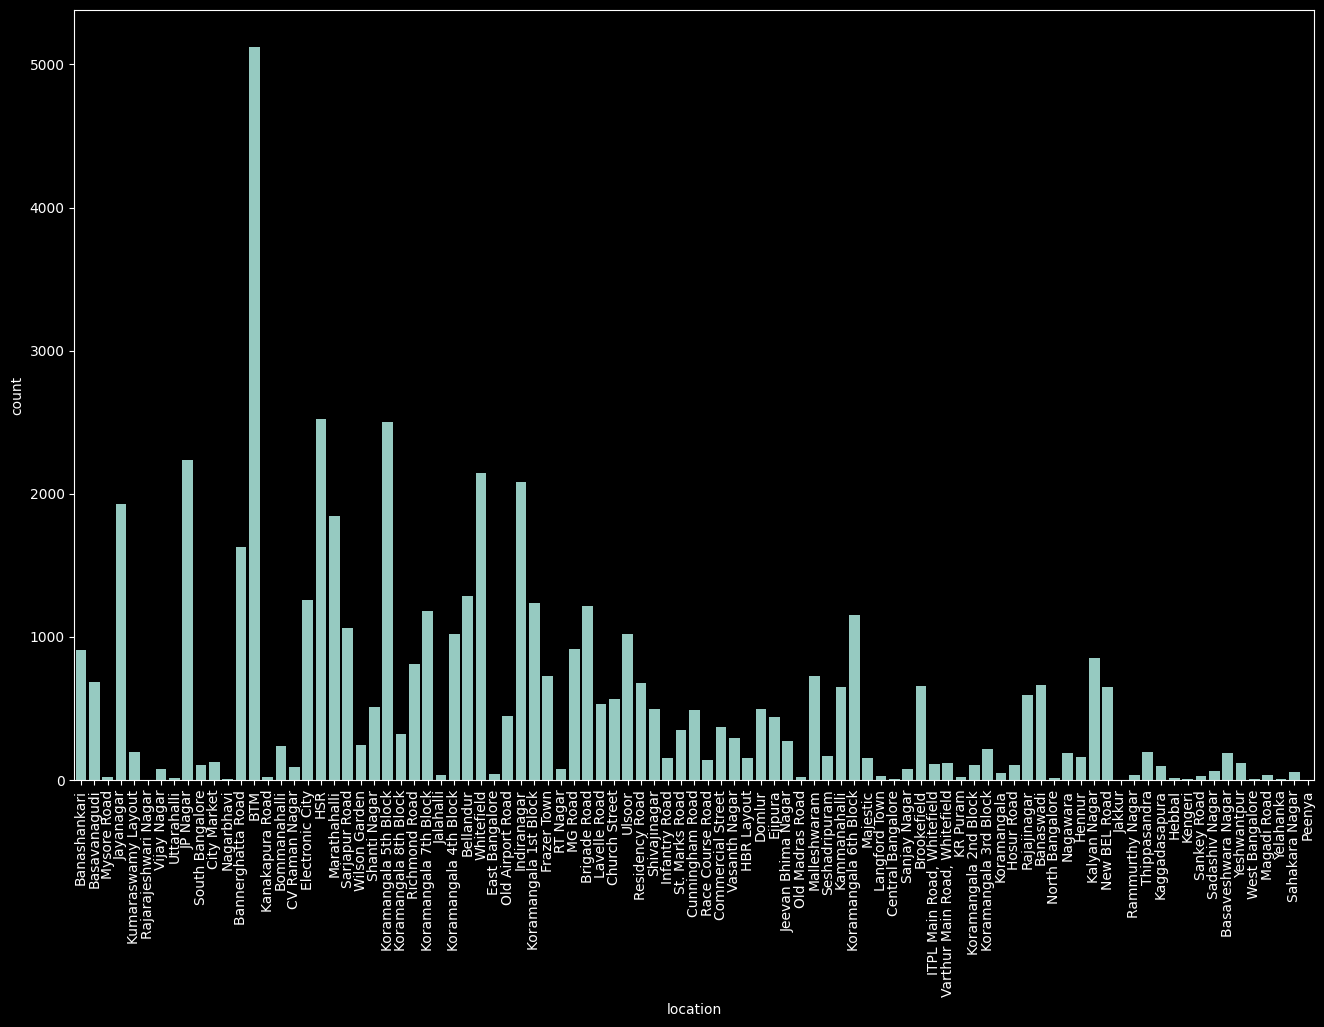

In [37]:
plt.figure(figsize=(16,10))
ax=sns.countplot(x='location' , data=df)
plt.xticks(rotation=90)

In [65]:
df.head(1)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari


/tmp/ipykernel_9687/2066573445.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['online_order'], palette='inferno')


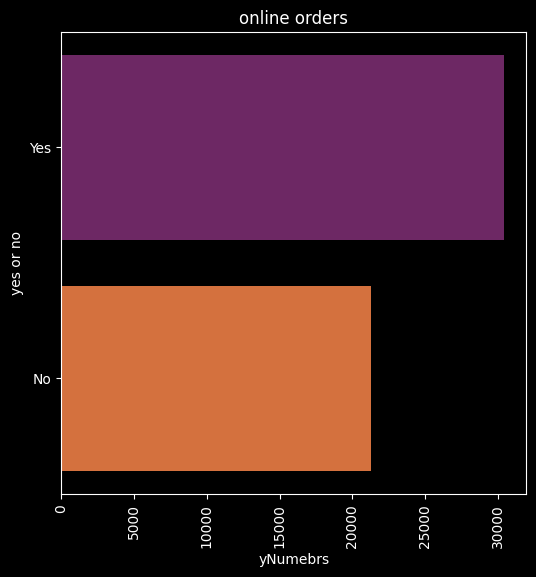

In [41]:
plt.figure(figsize=(6,6))
sns.countplot(df['online_order'], palette='inferno')
plt.xlabel('Numebrs')
plt.ylabel('yes or no')
plt.title('online orders')
plt.xticks(rotation=90)
plt.show()


/tmp/ipykernel_9687/2642469676.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['book_table'], palette='rainbow')


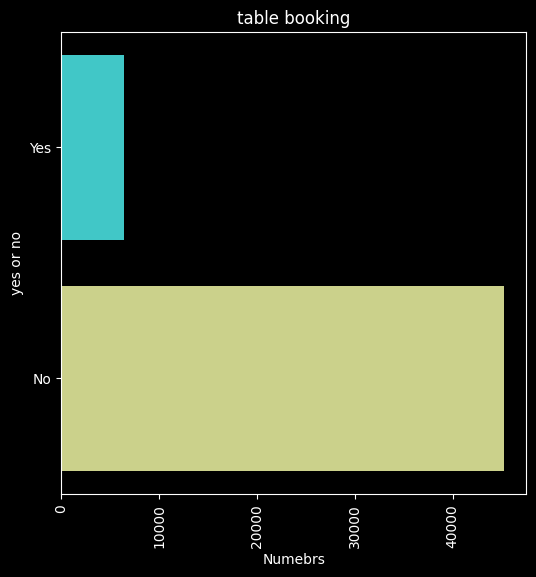

In [42]:
plt.figure(figsize=(6,6))
sns.countplot(df['book_table'], palette='rainbow')
plt.xlabel('Numebrs')
plt.ylabel('yes or no')
plt.title('table booking')
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='online_order', ylabel='rate'>

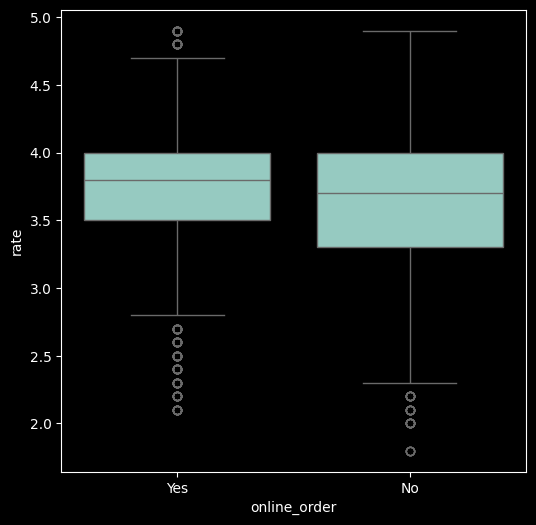

In [46]:
plt.figure(figsize=(6,6))
sns.boxplot(x='online_order', y='rate', data=df)


<Axes: xlabel='book_table', ylabel='rate'>

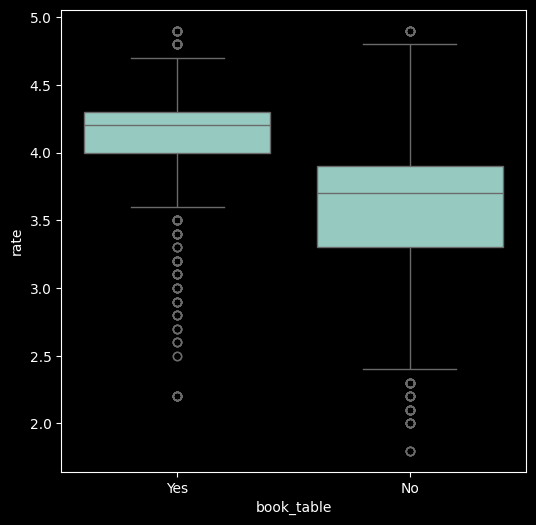

In [47]:
plt.figure(figsize=(6,6))
sns.boxplot(x='book_table', y='rate', data=df)

In [56]:
df1=df.groupby(['location','online_order'])['name'].count()
df1.to_csv('location_online.csv')
df1=pd.read_csv('location_online.csv')
df1=pd.pivot_table(df1, values=None, index=['location'], columns=['online_order'], fill_value=0, aggfunc=np.sum)
df1

/tmp/ipykernel_9687/3753367326.py:4: FutureWarning: The provided callable <function sum at 0x78079b928400> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df1=pd.pivot_table(df1, values=None, index=['location'], columns=['online_order'], fill_value=0, aggfunc=np.sum)


name      
online_order         No   Yes
location                     
BTM                1792  3332
Banashankari        397   509
Banaswadi           321   343
Bannerghatta Road   706   924
Basavanagudi        243   441
...                 ...   ...
West Bangalore        4     2
Whitefield         1005  1139
Wilson Garden       112   134
Yelahanka             1     5
Yeshwantpur          26    93

[93 rows x 2 columns]

<Axes: xlabel='location'>

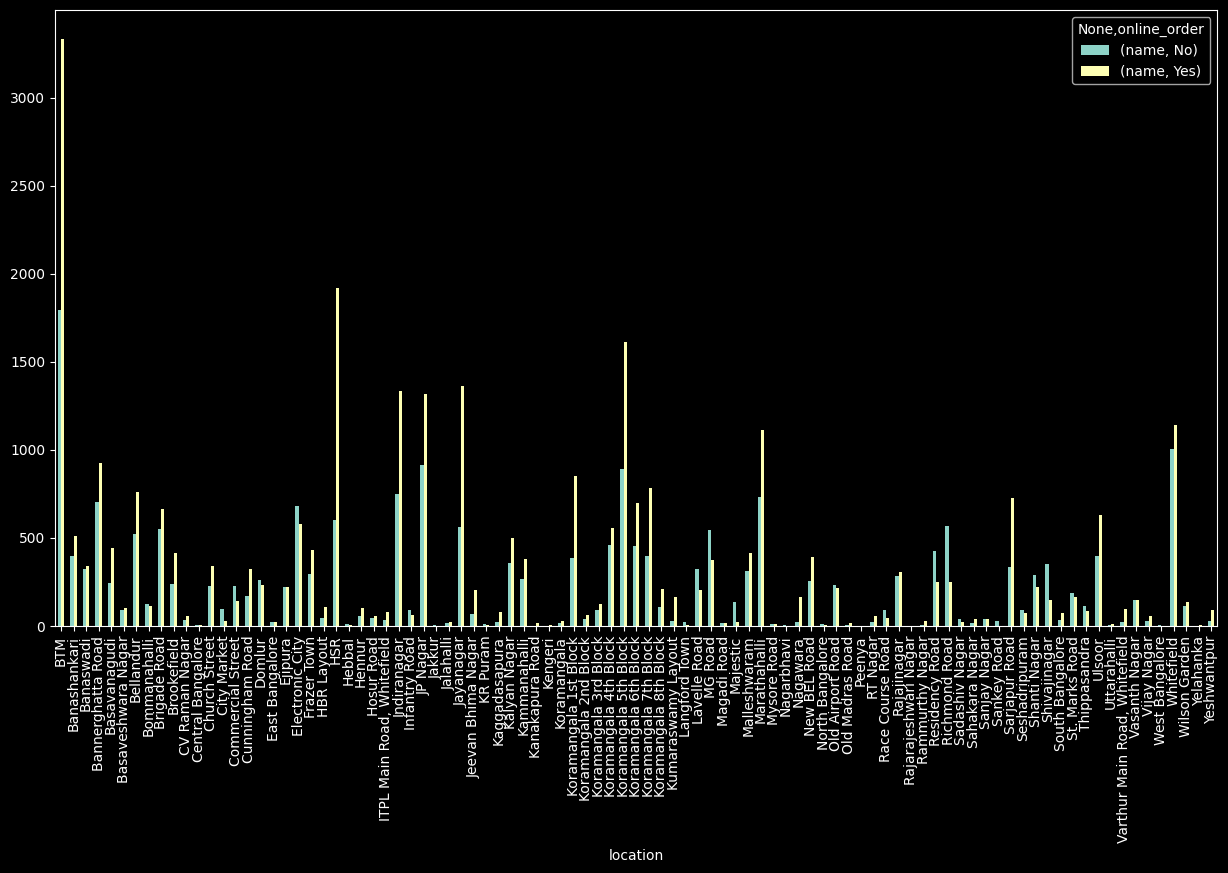

In [57]:
df1.plot(kind='bar' , figsize=(15,8))

In [60]:
df2=df.groupby(['location','book_table'])['name'].count()
df2.to_csv('location_booktable.csv')
df2=pd.read_csv('location_booktable.csv')
df2=pd.pivot_table(df2, values=None, index=['location'], columns=['book_table'], fill_value=0, aggfunc=np.sum)
df2

/tmp/ipykernel_9687/3637581961.py:4: FutureWarning: The provided callable <function sum at 0x78079b928400> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df2=pd.pivot_table(df2, values=None, index=['location'], columns=['book_table'], fill_value=0, aggfunc=np.sum)


name     
book_table           No  Yes
location                    
BTM                4956  168
Banashankari        842   64
Banaswadi           656    8
Bannerghatta Road  1531   99
Basavanagudi        668   16
...                 ...  ...
West Bangalore        6    0
Whitefield         1891  253
Wilson Garden       241    5
Yelahanka             6    0
Yeshwantpur         117    2

[93 rows x 2 columns]

<Axes: xlabel='location'>

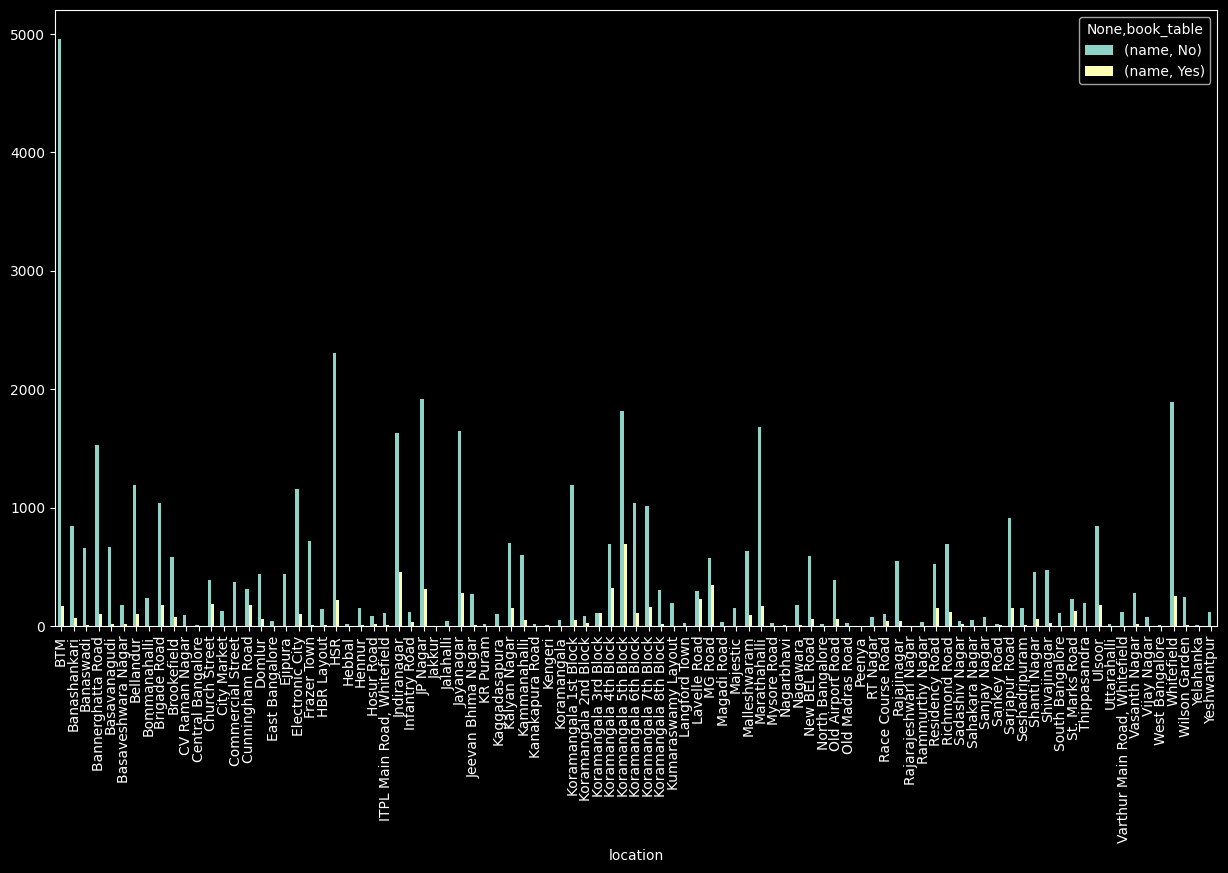

In [61]:
df2.plot(kind='bar' , figsize=(15,8))

/tmp/ipykernel_9687/3316844655.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x= 'Type', y='rate', data=df, palette='inferno')


<Axes: xlabel='Type', ylabel='rate'>

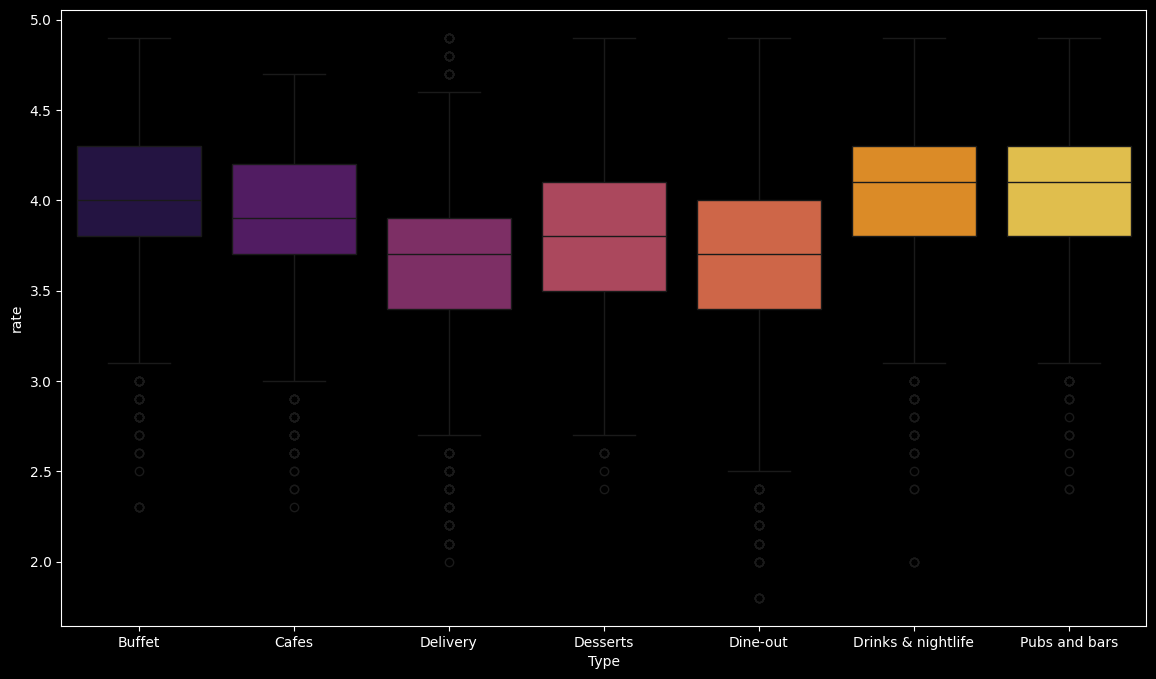

In [70]:
plt.figure(figsize=(14,8))
sns.boxplot(x= 'Type', y='rate', data=df, palette='inferno')

In [71]:
df3=df.groupby(['location','Type'])['name'].count()
df3.to_csv('location_type.csv')
df3=pd.read_csv('location_type.csv')
df3=pd.pivot_table(df3, values=None, index=['location'], columns=['Type'], fill_value=0, aggfunc=np.sum)
df3

/tmp/ipykernel_9687/1267150981.py:4: FutureWarning: The provided callable <function sum at 0x78079b928400> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df3=pd.pivot_table(df3, values=None, index=['location'], columns=['Type'], fill_value=0, aggfunc=np.sum)


name                                                      \
Type              Buffet Cafes Delivery Desserts Dine-out Drinks & nightlife   
location                                                                       
BTM                   25    83     3095      202     1678                 22   
Banashankari           7    36      420       71      358                 14   
Banaswadi              0    24      323       37      273                  6   
Bannerghatta Road      9    46      842      137      585                  9   
Basavanagudi           7    11      344       66      251                  5   
...                  ...   ...      ...      ...      ...                ...   
West Bangalore         0     0        5        0        1                  0   
Whitefield            28    51     1068      139      778                 47   
Wilson Garden          3     2      133       19       86                  2   
Yelahanka              0     0        4        0        2                  0   
Yeshwantpur            1     0       88        3       25                  1   

                                 
Type              Pubs and bars  
location                         
BTM                          19  
Banashankari                  0  
Banaswadi                     1  
Bannerghatta Road             2  
Basavanagudi                  0  
...                         ...  
West Bangalore                0  
Whitefield                   33  
Wilson Garden                 1  
Yelahanka                     0  
Yeshwantpur                   1  

[93 rows x 7 columns]

<Axes: xlabel='location'>

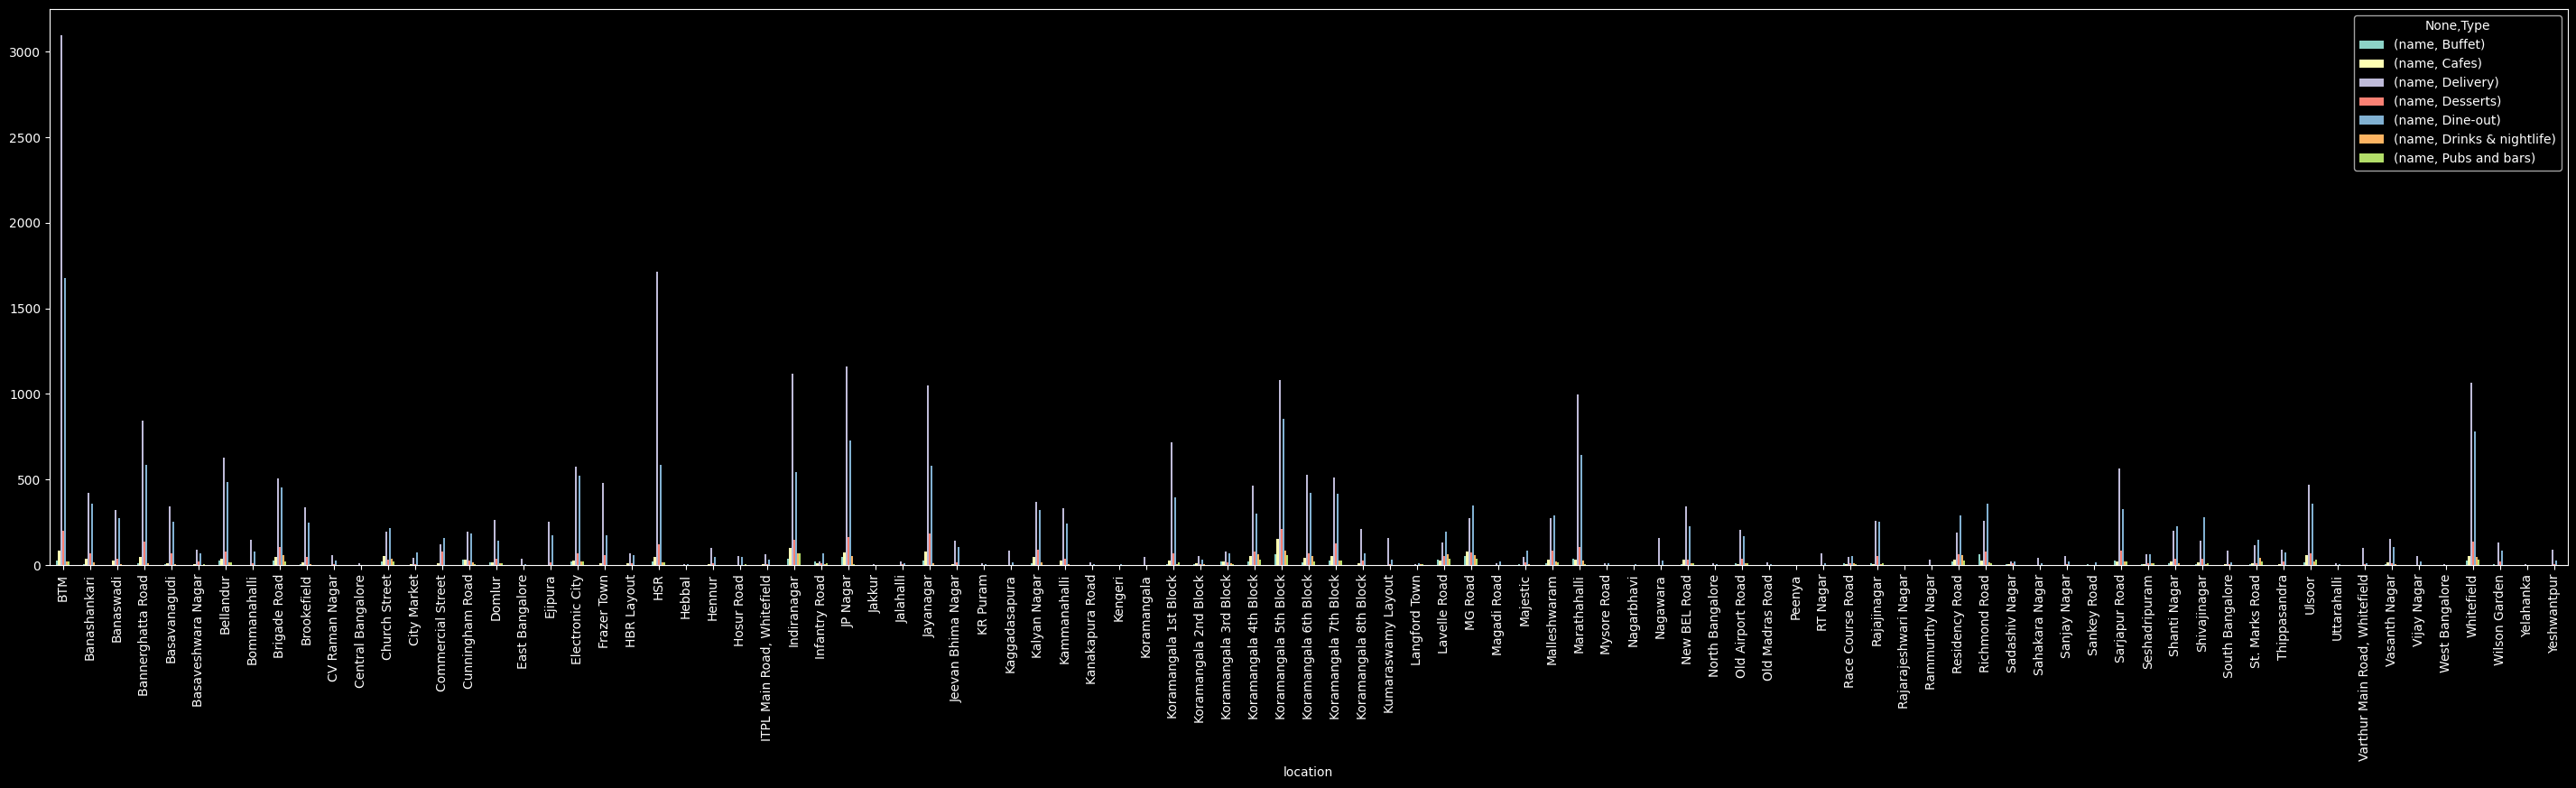

In [74]:
df3.plot(kind='bar', figsize=(36,8))

In [75]:
df4=df[['location', 'votes']]
df4.drop_duplicates()
df5=df4.groupby(['location'])['votes'].sum()
df5=df5.to_frame()
df5=df5.sort_values('votes', ascending=False)
df5.head()

,votes
location,
Koramangala 5th Block,2219506
Indiranagar,1196007
Koramangala 4th Block,685156
BTM,619376
Church Street,594979


In [78]:
df6=df[['cuisines', 'votes']]
df6.drop_duplicates()
df7=df6.groupby(['cuisines'])['votes'].sum()
df7=df7.to_frame()
df7=df7.sort_values('votes', ascending=False)
df7.head()

,votes
cuisines,
North Indian,558654
"Pizza, Cafe, Italian",347520
"Cafe, American, Burger, Steak",301059
"North Indian, Chinese",259864
"North Indian, Mughlai, South Indian, Chinese",227930


In [79]:
df7.iloc[1:, :]
df7.head()

,votes
cuisines,
North Indian,558654
"Pizza, Cafe, Italian",347520
"Cafe, American, Burger, Steak",301059
"North Indian, Chinese",259864
"North Indian, Mughlai, South Indian, Chinese",227930
